In [4]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import replace_utils4basic_rnn as utils

batch_size, num_steps = 32, 35
train_iter, vocab = utils.load_data_time_machine(batch_size, num_steps)

In [5]:
#粘贴必要函数
class RNNModel(nn.Module):
    '''循环神经网络模型'''
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        #判断是否为双向RNN
        if not self.rnn.bidirectional:
            self.num_directions = 1
            #全连接层，用于把RNN输出的隐藏状态映射到词汇表大小，用于预测下一个此的概率分布
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        #调用RNN层
        Y, state = self.rnn(X, state)
        #重塑并映射到词汇表
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            return torch.zeros((self.num_directions*self.rnn.num_layers, batch_size, self.num_hiddens),device=device)
        else:
            return (torch.zeros((
                self.num_directions*self.rnn.num_layers,
                batch_size, self.num_hiddens),device=device),
                torch.zeros((
                    self.num_directions*self.rnn.num_layers,
                    batch_size, self.num_hiddens),device=device))

def predict_ch8(prefix,num_preds,net,vocab,device):
    '''在prefix后面生成新字符'''
    state = net.begin_state(batch_size=1,device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda:torch.tensor([outputs[-1]],device=device).reshape((1,1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def grad_clipping(net,theta):
    '''裁剪梯度'''
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    for i, p in enumerate(params):
        if p.grad is None:
            print(f"Parameter {i} has None gradient")
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/ norm

def train_epoch_ch8(net, train_iter, loss, updater, device,use_random_iter):
    '''训练模型一个迭代周期'''
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0],device=device)
        else:
            if isinstance(net,nn.Module) and not isinstance(state,tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat,y.long()).mean()
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net,1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net,1)
            updater(batch_size=1)
        metric.add(l*y.numel(), y.numel())
    return math.exp(metric[0]/metric[1]), metric[1]/timer.stop()

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch',ylabel='perplexity',
                            legend=['train'],xlim=[10,num_epochs])
    if isinstance(net,nn.Module):
        updater = torch.optim.SGD(net.parameters(),lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params,lr,batch_size)
    predict = lambda prefix: predict_ch8(prefix,50,net,vocab,device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )
        if (epoch+1)%10 == 0:
            print(predict('timer traveller'))
            animator.add(epoch+1,[ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} tokens/sec {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

In [6]:
#通过num_layers的值来设定隐藏层数

#堆叠lstm层
vocab_size,num_hiddens,num_layers= len(vocab), 256, 2
num_inputs = vocab_size
device = d2l.try_gpu()
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers)
model = RNNModel(lstm_layer, len(vocab))
model = model.to(device)

困惑度 1.6, 242463.3 tokens/sec cuda:0
time traveller was one of those men and flowed about the leaves,
traveller put the lamp down on the edge, for the crawle in 
None


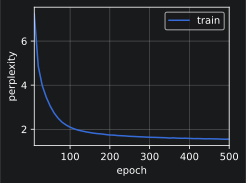

In [7]:
#训练
num_epochs, lr = 500, 2
print(train_ch8(model, train_iter, vocab, lr, num_epochs, device))